# Empirical results

**Paper organisation**

**4.1. Descriptive results**
- 4.1.1. Magnitude of the drift (Figure 2) (done, but SUE percentage isn't matching)
- 4.1.2. Relation of drift to firm size (Figure 3, 4) (done, data isn't looking the best)
- 4.1.3. Longevitiy of the drift (Table 1) (done, same data dynamic but not exact matches, just need some proper framing)

**4.2. Test of risk premiums as explanation for the drift**
- 4.2.1. Shifts in Betas
- 4.2.2. ATP risk factors as potential explanation
- 4.2.3. Consistent profitability of the strategy
- 4.2.4. Raw returns on bad news firms

**4.3. Tests of transactions costs as explanation for drift**
- 4.3.1. Upper bound constraint
- 4.3.2. Abnormal returns: long VS short

**4.4. Tests of whether prices fail to reflect full implication of current earnings for future earnings**

I think the "main empirical results" that we have to focus on are: 

**Part 4.1.**
- 4.1.1. Magnitude of the drift (FIG2)
- 4.1.2. Relation of the drift to firm size (FIG3, 4)
- 4.1.3. Longeviy of the drift (Table 1)

**Part 4.2.**
- 4.2.1. Shifts in betas as a potetial explanation (Table 2)
- 4.2.3. Consistent profitability of the strategy (Figure 5)

**Part 4.4**
- Test of whetheer prices fail to reflect full implications of current earnings for future earnings (Table 5)

## **4.1. Descriptive results**
### **4.1.1. Magnitude of the drift**

***FIG. 2.-Cumulative abnormal returns (CARs) for SUE portfolios: all announcements.***


*Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution. Based on 84,792 announcements from 1974 to 1986. CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile. SUE represents forecast errors from a first-order autoregressive earnings expectation model (in seasonal differences) scaled by its estimation-period standard deviation (see section 3.2 for details).*

Result: a long D1 - short D10 strat would yield a 4.2% abnormal return over the 60 days subsequent period (18%). It's 17% for the continuously balanced SUE.

- We need to compute CAR (cumulated Abnormal returns). CARs are the sums over pre- and postannouncement holding periods (beginning day -59 and day 1, respectively) of the difference between daily returns and returns for NYSE/AMEX firms of the same size decile
- Earnings announcements are assigned to deciles based on standing of standardized unexpected earnings (SUE) relative to prior-quarter SUE distribution.

We begin by loading SUE filtered quartered.

In [19]:
import pandas as pd
import numpy as np

df_sue_final = pd.read_csv("../data/OOS/SUE.csv")
df_sue_final['datadate'] = pd.to_datetime(df_sue_final['datadate'])
df_sue_final['gvkey'] = df_sue_final['gvkey'].astype(str)

We then assign SUE deciles based in prior-quarter distribution to avoid any hindsight bias that would magnify the drift.

In [20]:
df_sue_final['prev_fyearq'] = np.where(df_sue_final['fqtr'] == 1, df_sue_final['fyearq'] - 1, df_sue_final['fyearq'])
df_sue_final['prev_fqtr']   = np.where(df_sue_final['fqtr'] == 1, 4, df_sue_final['fqtr'] - 1)

# Compute decile boundaries from prior-quarter distribution
decile_bounds = (
    df_sue_final.groupby(['fyearq', 'fqtr'])['SUE']
    .quantile(np.arange(0.1, 1.0, 0.1))
    .unstack()
    .reset_index()
    .rename(columns={'fyearq': 'prev_fyearq', 'fqtr': 'prev_fqtr'})
)

# Rename quantile columns to avoid float key issue
decile_bounds.columns = ['prev_fyearq', 'prev_fqtr'] + [f'd{i}' for i in range(1, 10)]

df_sue_final = df_sue_final.merge(decile_bounds, on=['prev_fyearq', 'prev_fqtr'], how='left')

# Vectorized decile assignment using boundary columns
bound_cols = [f'd{i}' for i in range(1, 10)]
bounds_arr = df_sue_final[bound_cols].values
sue_arr    = df_sue_final['SUE'].values

# For each row, count how many boundaries the SUE exceeds → decile
df_sue_final['SUE_decile'] = (sue_arr[:, None] > bounds_arr).sum(axis=1) + 1

print(df_sue_final['SUE_decile'].value_counts().sort_index())

SUE_decile
1     8716
2     8121
3     8328
4     8290
5     8534
6     8512
7     8167
8     8234
9     8104
10    8830
Name: count, dtype: int64


We now compute Cumulative Abnormal Returns (CAR) on the -60,+60 days window surrounding an earnings announcement.

In [21]:
# /!\ memory intensive for 1m
dfD = pd.read_csv("../data/OOS/dfD_final_Abn.csv")

# For each firm-quarter, get the list of trading days around rdq
dfD['DlyCalDt'] = pd.to_datetime(dfD['DlyCalDt'])
df_sue_final['rdq'] = pd.to_datetime(df_sue_final['rdq'])

# Merge dfD with df_sue_final on PERMNO to get all daily returns per firm
dfD_small = dfD[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', "DlyRet"]].copy()
dfD_small = dfD_small.sort_values(['PERMNO', 'DlyCalDt'])
dfD_small['day_rank'] = dfD_small.groupby('PERMNO').cumcount()

rdq_ranks = df_sue_final[['gvkey', 'PERMNO', 'rdq', 'SUE_decile']].merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_rank'})

events = rdq_ranks[['gvkey', 'PERMNO', 'rdq', 'rdq_rank', 'SUE_decile']].dropna(subset=['rdq_rank'])
events['rdq_rank'] = events['rdq_rank'].astype(int)

# We filter before the merge
events['rank_min'] = events['rdq_rank'] - 60
events['rank_max'] = events['rdq_rank'] + 60

# Merge then filter
car_df = events.merge(dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'DlyRet', 'day_rank']], on='PERMNO', how='left')
car_df['rel_day'] = car_df['day_rank'] - car_df['rdq_rank']
car_df = car_df[(car_df['rel_day'] >= -60) & (car_df['rel_day'] <= 60)]

car_df = car_df.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df['CAR'] = car_df.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

# Average CAR by decile and relative day
car_avg = (
    car_df.groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

print(car_avg.head())
print(f"Deciles: {car_avg['SUE_decile'].unique()}")
print(f"Rel days: {car_avg['rel_day'].min()} to {car_avg['rel_day'].max()}")


   SUE_decile  rel_day       CAR
0           1      -60 -0.000330
1           1      -59 -0.001477
2           1      -58 -0.001798
3           1      -57 -0.002123
4           1      -56 -0.002466
Deciles: [ 1  2  3  4  5  6  7  8  9 10]
Rel days: -60 to 60


We now calculate long-short strategy returns, using both SUE and cont. SUE.

In [22]:
cont_SUE = pd.read_csv("../data/OOS/cont_SUE.csv")

# CAR-based long-short (D10 - D1) — all firms
car_pivot = car_avg.pivot(index='rel_day', columns='SUE_decile', values='CAR')
car_pivot['long_short'] = car_pivot[10] - car_pivot[1]
day0 = car_pivot.loc[0, 10] - car_pivot.loc[0, 1]
car_pivot['ls_norm'] = car_pivot['long_short'] - day0
r60_all  = car_pivot.loc[60, 'ls_norm'] * 100
ann_all  = ((1 + r60_all/100) ** (252/60) - 1) * 100

# Continuously balanced SUE — all firms
cont_agg = cont_SUE.groupby('match_day')[['r_ls']].mean().reset_index()
c60_all  = cont_agg['r_ls'].mean() * 100
cann_all = ((1 + c60_all/100) ** (252/60) - 1) * 100

print(f"{'Group':<10} {'CAR 60d':>10} {'CAR Ann.':>10} {'Cont 60d':>10} {'Cont Ann.':>10}")
print(f"{'All':<10} {r60_all:>9.2f}% {ann_all:>9.2f}% {c60_all:>9.2f}% {cann_all:>9.2f}%")

Group         CAR 60d   CAR Ann.   Cont 60d  Cont Ann.
All             4.24%     19.07%      3.36%     14.89%


**Comparison with the paper**

SUE 60d: 4.2.% (2.72%) (us)

SUE Ann.: 18% (11.91%) (us)

Cont. Ann.: 17% (15.33%) (us)

We can now plot Figure 2.

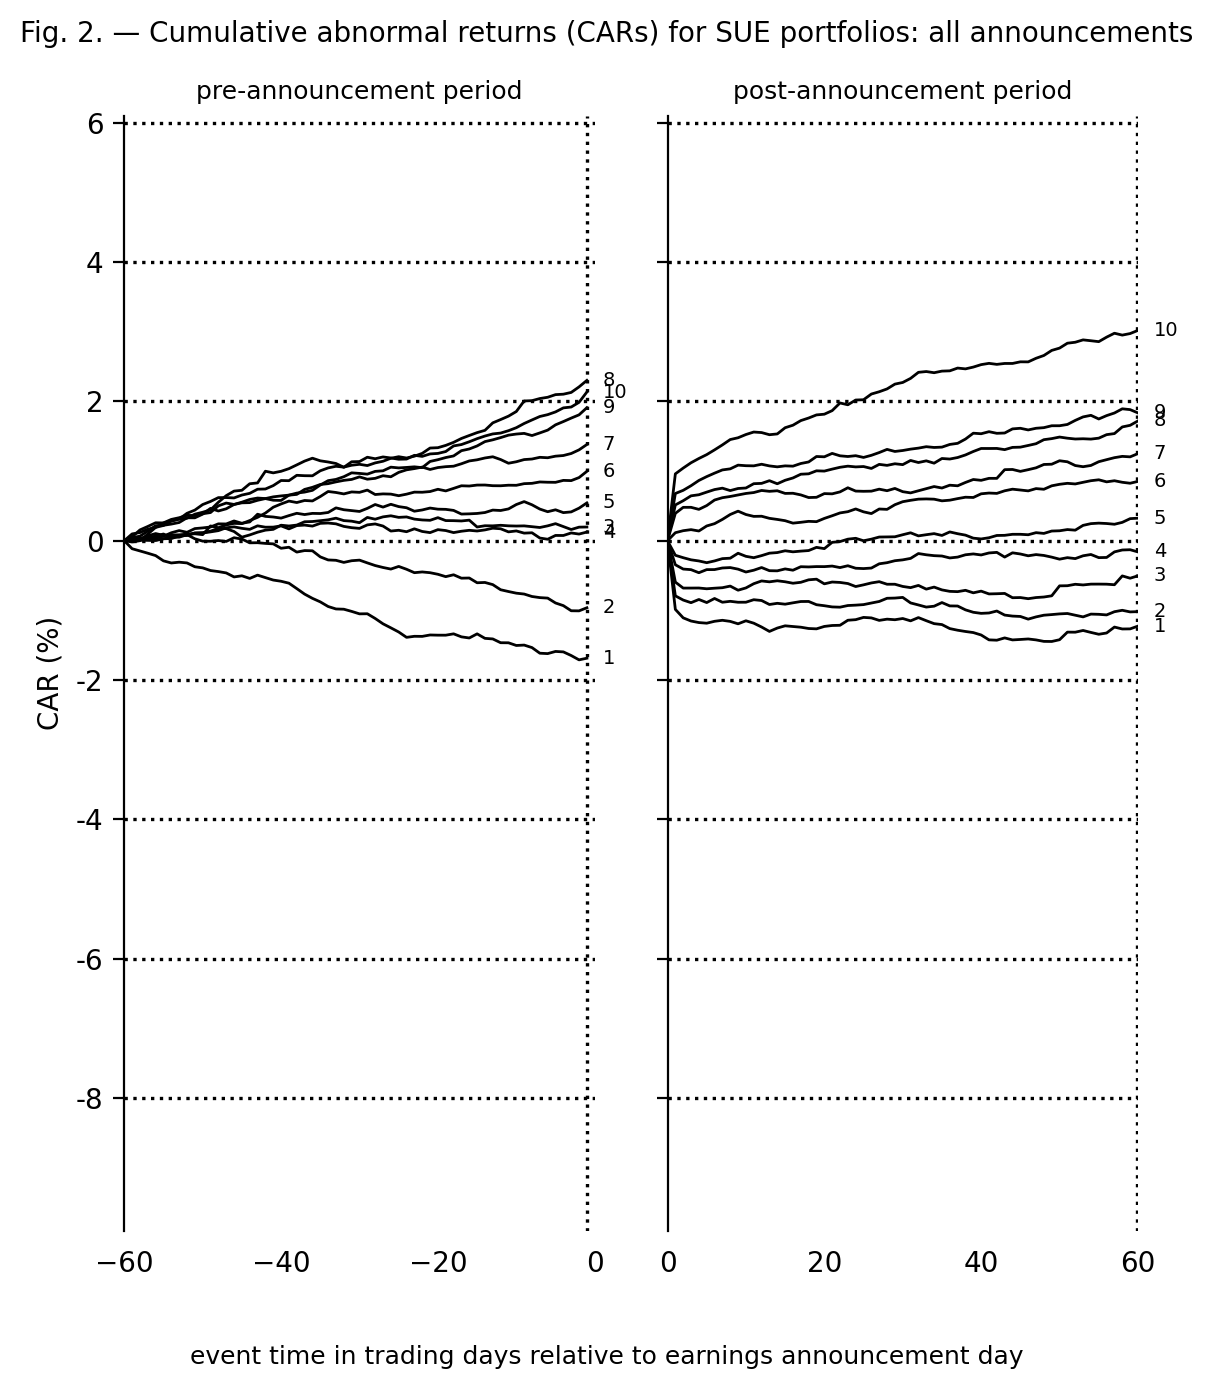

In [23]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=200)

for decile in range(1, 11):
    data = car_avg[car_avg['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')
    
# 6 to -8 unified axis for FIG 2, 3 and 4
for ax in [ax1, ax2]:
    ax.set_ylim(-9.9, 6.1)

ax1.axvline(x=-1, color='black', linewidth=1.2, linestyle=':')
ax2.axvline(x=59.9, color='black', linewidth=1.2, linestyle=':')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)
    ax.spines['top'].set_visible(False)   
    ax.spines['right'].set_visible(False)  
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 2. — Cumulative abnormal returns (CARs) for SUE portfolios: all announcements', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### **4.1.2. Relation of drift to firm size**

- Same graph, only for small firms (Figure 3)
- Same graph, only for large firms (Figure 4)
- Returns for small, medium and large firms
- Returns using continuously balanced SUE for small, medium and large firms

2 issues: we need to have the sizegroup: computing size group THEN quintiles. But if we do that, then the previous graph isn't working.

In [24]:
# Load SUE with SizeGroup
sue = pd.read_csv("../data/OOS/SUE_sizegroup.csv")[['gvkey', 'fyearq', 'fqtr', 'SizeGroup']]
sue['gvkey'] = sue['gvkey'].astype(str)

# Add fyearq, fqtr to car_df (needed for unique identification and SizeGroup merge)
car_df['gvkey'] = car_df['gvkey'].astype(str)
car_df_sized = car_df.merge(
    df_sue_final[['gvkey', 'rdq', 'fyearq', 'fqtr']].drop_duplicates(),
    on=['gvkey', 'rdq'],
    how='left'
).merge(sue, on=['gvkey', 'fyearq', 'fqtr'], how='left')

# Compute car_avg for small firms only
car_avg_large = (
    car_df_sized[car_df_sized['SizeGroup'] == 'large']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

# Compute car_avg for small firms only
car_avg_medium = (
    car_df_sized[car_df_sized['SizeGroup'] == 'medium']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

# Compute car_avg for small firms only
car_avg_small = (
    car_df_sized[car_df_sized['SizeGroup'] == 'small']
    .groupby(['SUE_decile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

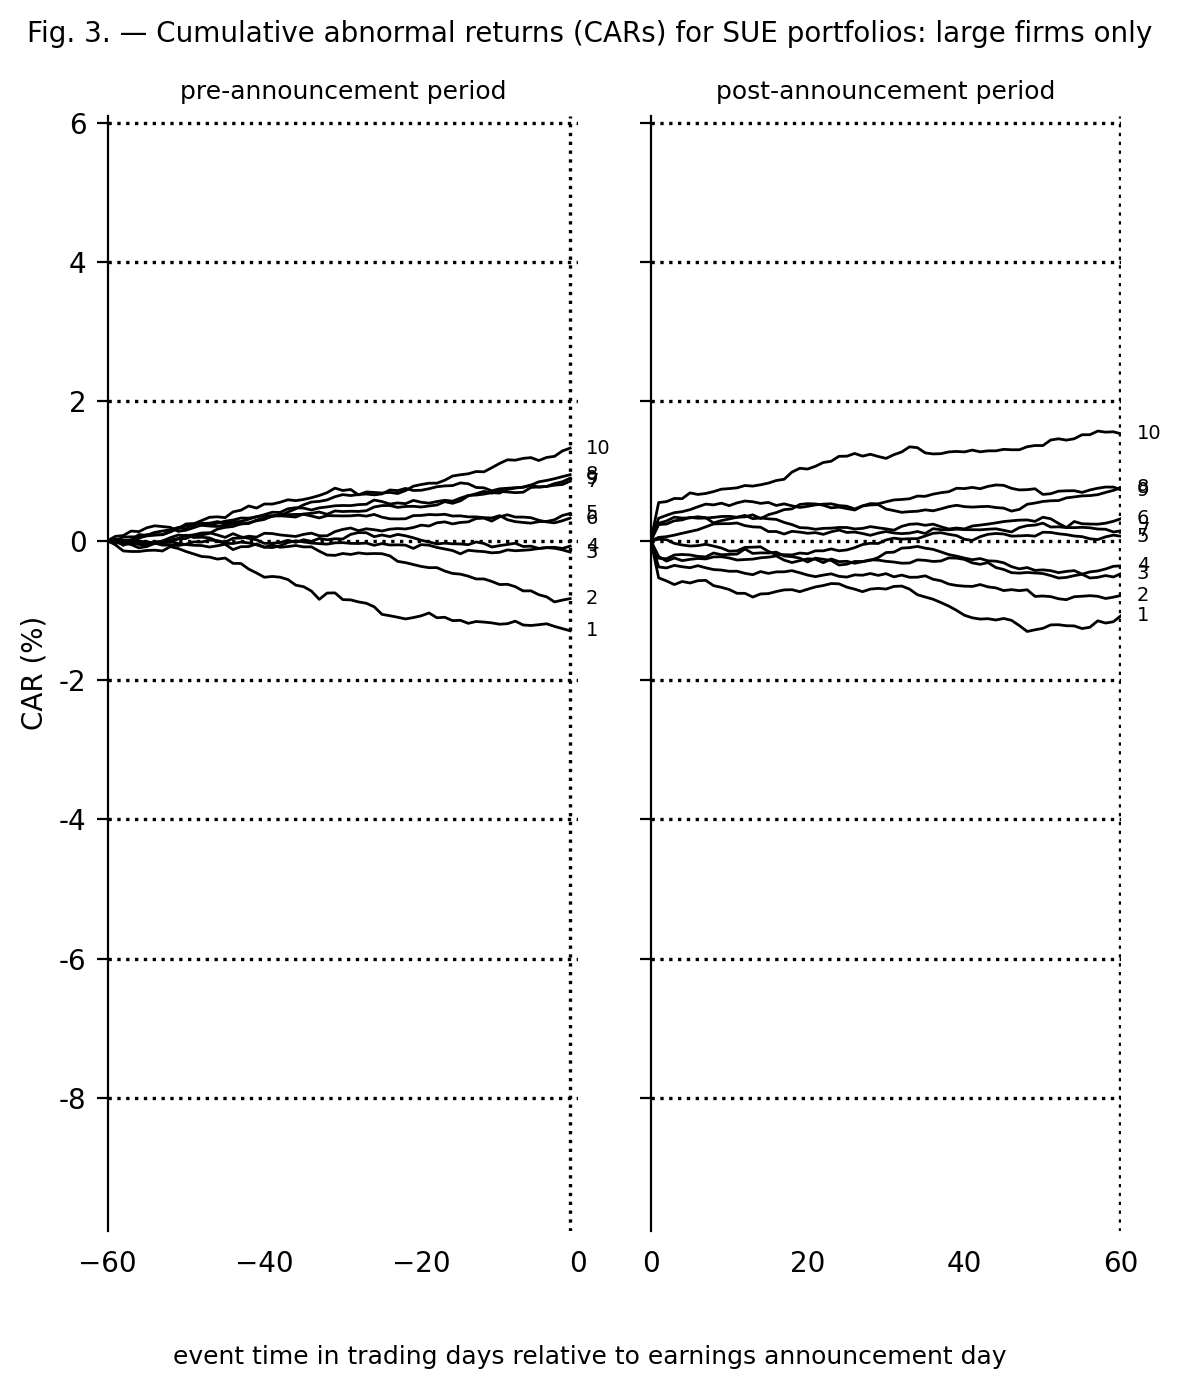

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=200)

for decile in range(1, 11):
    data = car_avg_large[car_avg_large['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

# 6 to -8 unified axis for FIG 2, 3 and 4
for ax in [ax1, ax2]:
    ax.set_ylim(-9.9, 6.1)

ax1.axvline(x=-1, color='black', linewidth=1.2, linestyle=':')
ax2.axvline(x=59.9, color='black', linewidth=1.2, linestyle=':')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)
    ax.spines['top'].set_visible(False)   
    ax.spines['right'].set_visible(False)  
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 3. — Cumulative abnormal returns (CARs) for SUE portfolios: large firms only', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

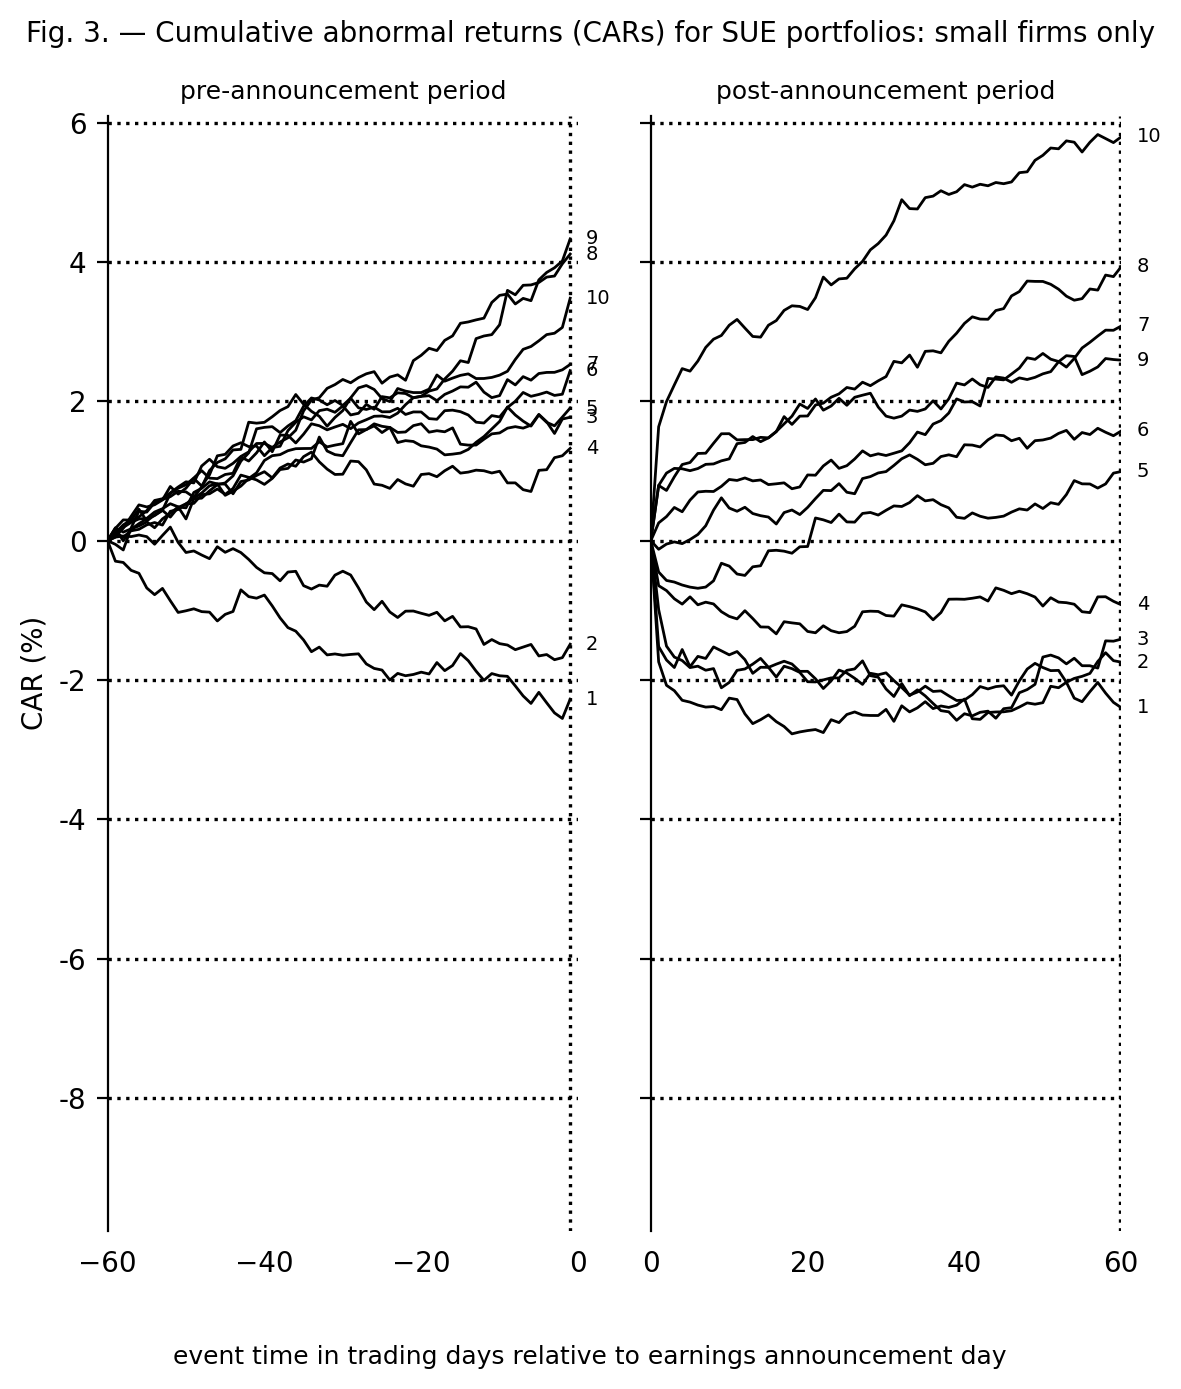

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 7), sharey=True, dpi=200)

for decile in range(1, 11):
    data = car_avg_small[car_avg_small['SUE_decile'] == decile]

    # Pre-announcement: days -60 to -1
    pre = data[(data['rel_day'] >= -60) & (data['rel_day'] < 0)].copy()
    pre['CAR_norm'] = (pre['CAR'] - pre.loc[pre['rel_day'] == -60, 'CAR'].values[0]) * 100
    ax1.plot(pre['rel_day'], pre['CAR_norm'], color='black', linewidth=1)
    last = pre[pre['rel_day'] == pre['rel_day'].max()]
    ax1.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

    # Post-announcement: days 0 to 60
    post = data[(data['rel_day'] >= 0) & (data['rel_day'] <= 60)].copy()
    post['CAR_norm'] = (post['CAR'] - post.loc[post['rel_day'] == 0, 'CAR'].values[0]) * 100
    ax2.plot(post['rel_day'], post['CAR_norm'], color='black', linewidth=1)
    last = post[post['rel_day'] == post['rel_day'].max()]
    ax2.text(last['rel_day'].values[0] + 2, last['CAR_norm'].values[0],
             str(decile), fontsize=7, color='black', va='center')

# 6 to -8 unified axis for FIG 2, 3 and 4
for ax in [ax1, ax2]:
    ax.set_ylim(-9.9, 6.1)

ax1.axvline(x=-1, color='black', linewidth=1.2, linestyle=':')
ax2.axvline(x=59.9, color='black', linewidth=1.2, linestyle=':')

ax1.set_xlim(-60, 0)
ax1.set_xticks(range(-60, 1, 20))
ax2.set_xlim(0, 60)
ax2.set_xticks(range(0, 61, 20))

for ax in [ax1, ax2]:
    ax.yaxis.set_tick_params(left=True, length=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.grid(axis='y', color='black', linestyle=':', linewidth=1.2)
    ax.spines['top'].set_visible(False)   
    ax.spines['right'].set_visible(False)  
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)

ax1.set_title('pre-announcement period', fontsize=9)
ax2.set_title('post-announcement period', fontsize=9)
ax2.tick_params(labelleft=False)
ax1.set_ylabel('CAR (%)', rotation=90)

fig.text(0.5, 0.02, 'event time in trading days relative to earnings announcement day',
         ha='center', fontsize=9)
plt.suptitle('Fig. 3. — Cumulative abnormal returns (CARs) for SUE portfolios: small firms only', fontsize=10)
plt.subplots_adjust(bottom=0.12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [27]:
print(f"{'Group':<10} {'CAR 60d':>10} {'CAR Ann.':>10} {'Cont 60d':>10} {'Cont Ann.':>10}")

for size_group, car_avg_group in [('small', car_avg_small), ('medium', car_avg_medium), ('large', car_avg_large)]:
    # CAR-based
    pivot = car_avg_group.pivot(index='rel_day', columns='SUE_decile', values='CAR')
    pivot['long_short'] = pivot[10] - pivot[1]
    day0 = pivot.loc[0, 10] - pivot.loc[0, 1]
    pivot['ls_norm'] = pivot['long_short'] - day0
    r60  = pivot.loc[60, 'ls_norm'] * 100
    ann  = ((1 + r60/100) ** (252/60) - 1) * 100

    # Continuous SUE
    cont_grp = cont_SUE[cont_SUE['size_group'] == size_group].groupby('match_day')[['r_ls']].mean().reset_index()
    c60  = cont_grp['r_ls'].mean() * 100
    cann = ((1 + c60/100) ** (252/60) - 1) * 100

    print(f"{size_group:<10} {r60:>9.2f}% {ann:>9.2f}% {c60:>9.2f}% {cann:>9.2f}%")

Group         CAR 60d   CAR Ann.   Cont 60d  Cont Ann.
small           8.19%     39.20%      6.93%     32.49%
medium          3.19%     14.11%      2.77%     12.17%
large           2.61%     11.41%      1.66%      7.17%


**Comparison with the paper**

SUE 60d small: 5.3% (8.1%) (us)

SUE 60d medium: 4.5% (2.6%) (us)

SUE 60d large: 2.8% (0.12%) (us)

Cont. 60d small: 5.1% (6.56%) (us)

Cont. 60d medium: 4.3% (3.13%) (us)

Cont. 60d large: 2.8% (1.62%) (us)

### **4.1.3. Longevity of the drift**

"*Table 1 provides information about the longevity of the postannouncement drift for stocks ranked in the lowest and highest SUE decile, broken down by size and by subperiods extending two years beyond the earnings announcement date.*"

This is a description of the regression table: 

They check the CAR for high and low SUE portfolios (those with SUE ranked in the highest and lowest deciles).

There are three main columns: Small Firms, Medium Firms and Large Firms. High of these are divided in 3 sub-columns: High SUE, Low SUE, Diff. (Hi-Lo).

With these columns, there are 3 large categories that each have different rows. 

Category 1: Cumulative Abnormal returns (%). Rows are Holding period (trading days, relative to announcement) There are: -59 to 0, 1 to 60, 61 to 120, 120 to 180, 181 to 240, 241 to 300, 301 to 360, 361 to 420, 421 to 480.

Category 2: Postannouncement drift (CAR, %). Rows are Holding period. There are: 1 to 60, 1 to 120, 1 to 180, 1 to 480.


Category 2: Postannouncement drift (as a fraction of 480-Day Drift). Rows are Holding period. There are: 1 to 60, 1 to 120, 1 to 180, 1 to 480.


We first need to recompute the window, from ±60 to -59,+480, keep only quarters with enough "longevity".

In [28]:
# We filter before the merge — extend to 480 days post-announcement
events_long = events.copy()
events_long['rank_min'] = events_long['rdq_rank'] - 59
events_long['rank_max'] = events_long['rdq_rank'] + 480

# Merge then filter
car_df_long = events_long.merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'day_rank']], 
    on='PERMNO', how='left'
)
car_df_long['rel_day'] = car_df_long['day_rank'] - car_df_long['rdq_rank']
car_df_long = car_df_long[(car_df_long['rel_day'] >= -59) & (car_df_long['rel_day'] <= 480)]

# SUE_decile already here from events — just add fyearq/fqtr then SizeGroup
sizegroup = pd.read_csv("../data/OOS/SUE_sizegroup.csv")
sizegroup['gvkey'] = sizegroup['gvkey'].astype(str)
car_df_long['gvkey'] = car_df_long['gvkey'].astype(str)

car_df_long = car_df_long.merge(
    df_sue_final[['gvkey', 'rdq', 'fyearq', 'fqtr']].drop_duplicates(),
    on=['gvkey', 'rdq'], how='left'
).merge(
    sizegroup[['gvkey', 'fyearq', 'fqtr', 'SizeGroup']],
    on=['gvkey', 'fyearq', 'fqtr'], how='left'
)

car_df_long = car_df_long.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df_long['CAR'] = car_df_long.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

#print(car_df_long.columns.tolist())
print(f"SUE_decile NAs: {car_df_long['SUE_decile'].isna().sum()}, total: {len(car_df_long)}")
print(f"Rel days: {car_df_long['rel_day'].min()} to {car_df_long['rel_day'].max()}")
print(f"Firm-quarters with 480 days: {(car_df_long.groupby(['gvkey','rdq'])['rel_day'].max() >= 480).sum()}")

SUE_decile NAs: 0, total: 42153206
Rel days: -59 to 480
Firm-quarters with 480 days: 68221


We can now build the table.

In [29]:
from scipy import stats

def get_stars(tstat):
    """Convert t-statistic to significance stars"""
    pval = 2 * (1 - stats.t.cdf(abs(tstat), df=1000))  # approx with large df
    if pval < 0.01:   return '***'
    elif pval < 0.05: return '**'
    elif pval < 0.10: return '*'
    else:             return ''

def car_stats(df, start, end):
    """Returns mean CAR (%) and significance stars for H0: mean CAR = 0"""
    window = df[(df['rel_day'] >= start) & (df['rel_day'] <= end)]
    car_per_fq = window.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].sum() * 100
    car_per_fq = car_per_fq.dropna()
    if len(car_per_fq) < 2:
        return np.nan, ''
    mean  = car_per_fq.mean()
    tstat = stats.ttest_1samp(car_per_fq, 0).statistic
    return mean, get_stars(tstat)

def car_diff_stats(df_hi, df_lo, start, end):
    """Returns Diff (Hi-Lo) CAR (%) and significance stars for H0: diff = 0"""
    def get_cars(df):
        window = df[(df['rel_day'] >= start) & (df['rel_day'] <= end)]
        return window.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].sum().dropna() * 100
    car_hi = get_cars(df_hi)
    car_lo = get_cars(df_lo)
    if len(car_hi) < 2 or len(car_lo) < 2:
        return np.nan, ''
    diff  = car_hi.mean() - car_lo.mean()
    tstat = stats.ttest_ind(car_hi, car_lo).statistic
    return diff, get_stars(tstat)

intervals_cat1 = [(-59, 0), (1, 60), (61, 120), (121, 180), (181, 240), (241, 300), (301, 360), (361, 420), (421, 480)]
intervals_cat2 = [(1, 60), (1, 120), (1, 180), (1, 480)]

rows = []

for size_group in ['small', 'medium', 'large']:
    grp    = car_df_long[car_df_long['SizeGroup'] == size_group]
    grp_hi = grp[grp['SUE_decile'] == 10]
    grp_lo = grp[grp['SUE_decile'] == 1]

    # High and Low rows — only Category 1
    for label, sub in [('High', grp_hi), ('Low', grp_lo)]:
        row = {'SizeGroup': size_group, 'SUE': label}
        for s, e in intervals_cat1:
            mean, stars = car_stats(sub, s, e)
            row[f'C1 {s}:{e}'] = f'{mean:.2f}{stars}'
        rows.append(row)

    # Diff row — Category 1, 2 and 3
    row = {'SizeGroup': size_group, 'SUE': 'Diff'}

    # Category 1
    for s, e in intervals_cat1:
        diff, stars = car_diff_stats(grp_hi, grp_lo, s, e)
        row[f'C1 {s}:{e}'] = f'{diff:.2f}{stars}'
        

    # Category 2 — only Diff
    for _, e in intervals_cat2:
        diff, stars = car_diff_stats(grp_hi, grp_lo, 1, e)
        row[f'C2 1:{e}'] = f'{diff:.2f}{stars}'

    # Category 3 — only Diff, as fraction of 1-480 diff
    drift_480_hi, _ = car_stats(grp_hi, 1, 480)
    drift_480_lo, _ = car_stats(grp_lo, 1, 480)
    drift_480_diff  = drift_480_hi - drift_480_lo
    for _, e in intervals_cat2:
        diff, _ = car_diff_stats(grp_hi, grp_lo, 1, e)
        frac = diff / drift_480_diff if drift_480_diff != 0 else np.nan
        row[f'C3 1:{e}'] = f'{frac:.2f}'

    rows.append(row)

table1 = pd.DataFrame(rows)
table1 = table1.sort_values(['SizeGroup', 'SUE']).reset_index(drop=True)
print(table1.to_string())

  SizeGroup   SUE  C1 -59:0   C1 1:60 C1 61:120 C1 121:180 C1 181:240 C1 241:300 C1 301:360 C1 361:420 C1 421:480  C2 1:60 C2 1:120 C2 1:180 C2 1:480 C3 1:60 C3 1:120 C3 1:180 C3 1:480
0     large  Diff   3.78***   2.56***      0.48    -0.75**      -0.31   -1.00***       0.26       0.48   -1.00***  2.56***  3.03***  2.30***     0.85    3.01     3.58     2.71     1.00
1     large  High   1.96***   1.49***   0.59***      -0.27       0.17      -0.31       0.08      0.43*   -0.71***      NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN
2     large   Low  -1.82***  -1.07***      0.11     0.48**      0.49*    0.69***      -0.18      -0.05       0.30      NaN      NaN      NaN      NaN     NaN      NaN      NaN      NaN
3    medium  Diff   5.04***   3.22***      0.05      -0.22      -0.52      -0.83      -0.11      -0.00       0.69  3.22***  3.27***  3.05***     2.26    1.42     1.45     1.35     1.00
4    medium  High   2.71***   2.68***      0.21     0.73**     0.82**      

## **4.1. Tests of risk premiums as explanation for the drift**
### **4.2.1. Shifts in betas as a potential explanation**

Idea: "*Beta shifts are obviously a concern in a design that estimates betas in one period and then uses those estimates in a different period*."

What we check: "*Thus, while we examine the BKW hypothesis that betas shift around the time of earnings announcements, our ultimate concern is with any differences in the levels of betas for high- and low-SUE firms in the postannouncement period.*"

Beta estimate: derived using the BKW methodology for permitting betas to shift through time. For each of several 60-day windows surrounding the earnings announcement, we compounded:
- total returns on invididual stocks ($R_{jt}$)
- treasury bills ($R_{ft}$) derived on a daily basis from weekly returns calculated by Gautam Kaul for bills in their final week before maturity. Kaul's weekly returns were allocated to days assuming the same return for each day within the day.
- value-weighted CRSP index ($R_{mt}$)

These trhee data points constitute a single observation for a regression based on the Sharpe-Lintner-Mossin CAPM: $$R_{jt}=R_{fr}=a+b(R_{mt}-R_{ft})+e_{jt}$$

The regression was estimated by pooling all observations for a given SUE decile, within six 60-trading-day window surrounding the ernings announcement date. 

*Table 2 description: Beta estimates by SUE category, in periods surrounding earnings announcement. For each 60-day window, we calculate compounded daily returns for individual stocks, the value-weighted CRSP index, and the treasury-bill rate. These data constitute a single observation in a regression of individual stock returns against market returns, both expressed in terms of differences from the treasury-bill rate. Such regressions are estimated within each SUE category. There are approximately 8,500 (overlapping and thus nonindependent) observations underlying estimates for the (-59, 0) and (1, 60) windows, and slightly fewer for other windows. The standard error for each estimate in the table is approximately 0.02. Cross-sectional dependence in the data may cause downward bias in the estimated standard error (Bernard [1987]).*

**Column 1**: Preannouncement period. Subcolumns: (-119,60) and (-59, 0)

**Column 2**: Postannouncement period. Subcolumns: (1,60), (61-120), (121, 180), (181, 240)

Rows for category 1 with all these columns: Beta estimate: from 1 through 10. For category 2: Rank correlation: only 1 row (SUE and beta). For category 3: Jensen's alpha: SUE=1, SUE=10 and combined.

We only add statistical tests for category 2 & 3, with only * or nothing, with * indicating Significantly different from zero, .05 level (two-tailed test).

For the treasury bills rate and the value-weighted CRSP index, we use [Fama/French 3 Factors (Daily)](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) file. Mkt_RF is value-weighted CRSP indux minus RF, and RF is the risk-free rate.

In [30]:
ff = pd.read_csv("../data/WRDS/F-F_3Factors_daily.csv", sep=';')
ff.columns = ['Date', 'Mkt_RF', 'SMB', 'HML', 'RF']
ff['Date'] = pd.to_datetime(ff['Date'].astype(str), format='%Y%m%d')
ff[['Mkt_RF', 'SMB', 'HML', 'RF']] = ff[['Mkt_RF', 'SMB', 'HML', 'RF']].astype(float) / 100

ff['Rm'] = ff['Mkt_RF'] + ff['RF']
ff = ff[['Date', 'RF', 'Rm']]

# We filter our selected period
ff = ff[(ff['Date'] >= '2012-01-01') & (ff['Date'] <= '2024-12-31')]
print(ff.head())

            Date   RF      Rm
22631 2012-01-03  0.0  0.0150
22632 2012-01-04  0.0  0.0000
22633 2012-01-05  0.0  0.0039
22634 2012-01-06  0.0 -0.0019
22635 2012-01-09  0.0  0.0028


We then build observations for the regression: daily returns per firm quarters.

In [31]:
# Get trading day index per PERMNO
dfD_idx = dfD[['PERMNO', 'DlyCalDt', 'DlyRet']].copy()
dfD_idx = dfD_idx.sort_values(['PERMNO', 'DlyCalDt'])
dfD_idx['day_rank'] = dfD_idx.groupby('PERMNO').cumcount()

# Get rdq rank for each firm-quarter
rdq_rank = df_sue_final[['gvkey', 'PERMNO', 'rdq', 'SUE_decile']].copy()
rdq_rank['rdq'] = pd.to_datetime(rdq_rank['rdq'])

rdq_rank = rdq_rank.merge(
    dfD_idx[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_rank'}).drop(columns='DlyCalDt')

rdq_rank = rdq_rank.dropna(subset=['rdq_rank'])
rdq_rank['rdq_rank'] = rdq_rank['rdq_rank'].astype(int)

print(f"{len(rdq_rank)} firm-quarters with rdq matched")
#print(rdq_rank.head(3))

83850 firm-quarters with rdq matched


Then, for each firm-quarter, we get daily returns in each window.

In [32]:
# Very long (7min)
windows = [(-119, -60), (-59, 0), (1, 60), (61, 120), (121, 180), (181, 240)]
obs_list = []

for start, end in windows:
    # Filter daily returns to window
    w = rdq_rank[['gvkey', 'PERMNO', 'rdq', 'SUE_decile', 'rdq_rank']].copy()
    w['rank_min'] = w['rdq_rank'] + start
    w['rank_max'] = w['rdq_rank'] + end

    daily = w.merge(dfD_idx, on='PERMNO', how='left')
    daily = daily[(daily['day_rank'] >= daily['rank_min']) & (daily['day_rank'] <= daily['rank_max'])]
    daily = daily.merge(ff.rename(columns={'Date': 'DlyCalDt'}), on='DlyCalDt', how='left')
    daily = daily.dropna(subset=['DlyRet', 'Rm', 'RF'])

    # Vectorized compounding: log returns then sum, then exp
    daily['log_Rj'] = np.log1p(daily['DlyRet'])
    daily['log_Rm'] = np.log1p(daily['Rm'])
    daily['log_Rf'] = np.log1p(daily['RF'])

    compounded = daily.groupby(['gvkey', 'rdq', 'SUE_decile'])[['log_Rj', 'log_Rm', 'log_Rf']].sum()
    compounded['R_j'] = np.expm1(compounded['log_Rj'])
    compounded['R_m'] = np.expm1(compounded['log_Rm'])
    compounded['R_f'] = np.expm1(compounded['log_Rf'])
    compounded['n_days'] = daily.groupby(['gvkey', 'rdq', 'SUE_decile']).size()
    compounded = compounded[['R_j', 'R_m', 'R_f', 'n_days']].reset_index()

    compounded['window'] = f'{start} to {end}'
    obs_list.append(compounded)
    print(f"{start} to {end}: {len(compounded)} obs, mean n_days={compounded['n_days'].mean():.1f}, mean R_j={compounded['R_j'].mean():.4f}")

obs_df = pd.concat(obs_list, ignore_index=True)
obs_df['R_j_excess'] = obs_df['R_j'] - obs_df['R_f']
obs_df['R_m_excess'] = obs_df['R_m'] - obs_df['R_f']

-119 to -60: 83830 obs, mean n_days=59.6, mean R_j=0.0327
-59 to 0: 83831 obs, mean n_days=60.0, mean R_j=0.0280
1 to 60: 83831 obs, mean n_days=60.0, mean R_j=0.0316
61 to 120: 83831 obs, mean n_days=59.4, mean R_j=0.0320
121 to 180: 81777 obs, mean n_days=59.2, mean R_j=0.0338
181 to 240: 79379 obs, mean n_days=59.1, mean R_j=0.0298


In [33]:
# OLS regression pooled by SUE decile and window
reg_results = []

for window in obs_df['window'].unique():
    w_df = obs_df[obs_df['window'] == window].dropna(subset=['R_j_excess', 'R_m_excess'])

    for decile in range(1, 11):
        sub = w_df[w_df['SUE_decile'] == decile]
        if len(sub) < 10: continue

        slope, intercept, _, _, se = stats.linregress(sub['R_m_excess'], sub['R_j_excess'])

        reg_results.append({
            'window'    : window,
            'SUE_decile': decile,
            'beta'      : slope,
            'alpha'     : intercept,
            'se'        : se,
            'n'         : len(sub)
        })

df_reg = pd.DataFrame(reg_results)

def star(val, se, n):
    """* if significantly different from zero at .05 two-tailed"""
    t = val / se
    p = 2 * (1 - stats.t.cdf(abs(t), df=n-2))
    return '*' if p < 0.05 else ''

# Build table
window_order = ['-119 to -60', '-59 to 0', '1 to 60', '61 to 120', '121 to 180', '181 to 240']
rows = []

# Category 1: Beta estimates by decile
for decile in range(1, 11):
    row = {'Category': 'Beta', 'Label': f'{decile}'}
    for w in window_order:
        r = df_reg[(df_reg['window'] == w) & (df_reg['SUE_decile'] == decile)]
        if len(r):
            row[w] = f"{r['beta'].values[0]:.2f}"
    rows.append(row)

# Category 2: Rank correlation (SUE decile vs beta)
row = {'Category': 'Rank correlation', 'Label': 'SUE and beta'}
for w in window_order:
    betas = df_reg[df_reg['window'] == w].sort_values('SUE_decile')['beta'].values
    deciles = np.arange(1, 11)
    rho, pval = stats.spearmanr(deciles, betas)
    s = '*' if pval < 0.05 else ''
    row[w] = f"{rho:.2f}{s}"
rows.append(row)

# Category 3: Jensen's alpha
for label, decile in [('1', 1), ('10', 10)]:
    row = {'Category': "Jensen's alpha", 'Label': label}
    for w in window_order:
        r = df_reg[(df_reg['window'] == w) & (df_reg['SUE_decile'] == decile)]
        if len(r):
            alpha = r['alpha'].values[0]
            se    = r['se'].values[0]
            n     = r['n'].values[0]
            s     = star(alpha, se, n)
            row[w] = f"{alpha*100:.1f}{s}"
    rows.append(row)

# Combined alpha (SUE=10 minus SUE=1)
row = {'Category': "Jensen's alpha", 'Label': 'Combined'}
for w in window_order:
    r1  = df_reg[(df_reg['window'] == w) & (df_reg['SUE_decile'] == 1)]
    r10 = df_reg[(df_reg['window'] == w) & (df_reg['SUE_decile'] == 10)]
    if len(r1) and len(r10):
        combined = (r10['alpha'].values[0] - r1['alpha'].values[0]) * 100
        # Approximate SE for difference
        se_combined = np.sqrt(r1['se'].values[0]**2 + r10['se'].values[0]**2)
        s = star(combined/100, se_combined, r1['n'].values[0] + r10['n'].values[0])
        row[w] = f"{combined:.1f}{s}"
rows.append(row)

table2 = pd.DataFrame(rows).set_index(['Category', 'Label'])[window_order]
print(table2.to_string())

                              -119 to -60 -59 to 0 1 to 60 61 to 120 121 to 180 181 to 240
Category         Label                                                                    
Beta             1                   1.39     1.44    1.34      1.51       1.54       1.33
                 2                   1.51     1.32    1.23      1.39       1.41       1.30
                 3                   1.37     1.29    1.30      1.42       1.37       1.33
                 4                   1.35     1.22    1.23      1.35       1.39       1.34
                 5                   1.34     1.20    1.34      1.33       1.36       1.39
                 6                   1.30     1.29    1.33      1.37       1.40       1.28
                 7                   1.41     1.21    1.35      1.38       1.34       1.33
                 8                   1.40     1.33    1.45      1.35       1.30       1.26
                 9                   1.37     1.28    1.38      1.33       1.30       1.14

### **4.2.3. Consistent profitability of the strategy**

We examine how frequently a zero-investment SUE trading strategy generates a negative return.

Two strategies: 
- A: basic SUE, long (short) in the firms whose unexpected earnings are ranked in the highest (lowest) quintile. In panel A, CARs are the combined abnormal returns from a long position in the highest SUE quintile and a short position -in the lowest SUE quintile. 
- B: Cont. SUE strategy

We calculate abnormal returns over 60-trading-day post-announcement windows and then determined how much of the 60-day return was generated within the two calendar quarters spanned by those 60 days.


Graph: 2 bar graphs, one for each strategy.
- x: CAR (%)
- y: year, by quarter (4 barres par année)


We begin by loading our data. We use the version of SUE that had the Q1/Q5 computation then the sizegroup filter: missing quarters aren't an issue as then aren't taken into account for the long short calculation.

In [34]:
sue = pd.read_csv('../data/OOS/SUE_Q1Q5_size.csv')
sue['rdq'] = pd.to_datetime(sue['rdq'])
print(sue['SUE_quintile'].value_counts().sort_index())

SUE_quintile
1.0    16765
5.0    16937
Name: count, dtype: int64


We then compute the CARs.

In [35]:
rdq_ranks = sue[['gvkey', 'PERMNO', 'rdq', 'SUE_quintile']].merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_rank'}) 

events = rdq_ranks[['gvkey', 'PERMNO', 'rdq', 'rdq_rank', 'SUE_quintile']].dropna(subset=['rdq_rank'])
events['rdq_rank'] = events['rdq_rank'].astype(int)

# We filter before the merge
events['rank_min'] = events['rdq_rank']
events['rank_max'] = events['rdq_rank'] + 60

# Merge then filter
car_df = events.merge(dfD_small[['PERMNO', 'DlyCalDt', 'DlyAbnReturn', 'DlyRet', 'day_rank']], on='PERMNO', how='left')
car_df['rel_day'] = car_df['day_rank'] - car_df['rdq_rank']
car_df = car_df[(car_df['rel_day'] >= 0) & (car_df['rel_day'] <= 60)]

car_df = car_df.sort_values(['gvkey', 'rdq', 'rel_day'])
car_df['CAR'] = car_df.groupby(['gvkey', 'rdq'])['DlyAbnReturn'].cumsum()

# Average CAR by quintile and relative day
car_avg = (
    car_df.groupby(['SUE_quintile', 'rel_day'])['CAR']
    .mean()
    .reset_index()
)

print(car_avg.head())
print(f"Quintiles: {car_avg['SUE_quintile'].unique()}")
print(f"Rel days: {car_avg['rel_day'].min()} to {car_avg['rel_day'].max()}")


   SUE_quintile  rel_day       CAR
0           1.0        0 -0.005497
1           1.0        1 -0.014391
2           1.0        2 -0.015327
3           1.0        3 -0.015749
4           1.0        4 -0.015652
Quintiles: [1. 5.]
Rel days: 0 to 60


We then measure long/short returns per quarter, for strategies held for 60 trading days. *CARs are assigned to calendar quarters based on the portion of the 60-day CAR generated within that calendar quarter*. We can plot the result for strategy A.

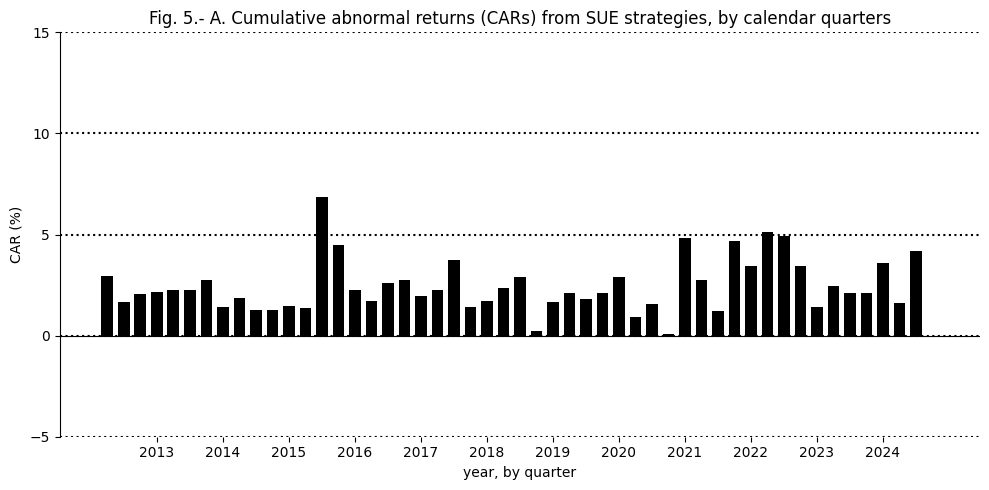

In [36]:
# Quarters
car_df['calendar_quarter'] = car_df['DlyCalDt'].dt.to_period('Q')

# Partial CAR per quarter per event
car_df['quarter_CAR'] = car_df.groupby(['gvkey', 'rdq', 'calendar_quarter'])['DlyAbnReturn'].cumsum()
quarterly_car = car_df[car_df['rel_day'] == car_df.groupby(['gvkey', 'rdq', 'calendar_quarter'])['rel_day'].transform('max')].copy()

# Long-short per quarter with partial CARs
ls_by_quarter = []
for q in sorted(quarterly_car['calendar_quarter'].unique()):
    q_data = quarterly_car[quarterly_car['calendar_quarter'] == q]
    long_q = q_data[q_data['SUE_quintile'] == 5.0]['quarter_CAR'].mean()
    short_q = q_data[q_data['SUE_quintile'] == 1.0]['quarter_CAR'].mean()
    ls_by_quarter.append({'quarter': str(q), 'return': long_q - short_q})

ls_df = pd.DataFrame(ls_by_quarter)
returns_pct = ls_df['return'] * 100


# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(len(ls_df)), returns_pct, width=0.7, color='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylim(-5, 15)
ax.set_yticks([-5, 0, 5, 10, 15])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.yaxis.grid(True, linestyle=':', linewidth=1.5, color='black')

ax.set_xlabel('year, by quarter')
ax.set_ylabel('CAR (%)')
ax.set_title('Fig. 5.- A. Cumulative abnormal returns (CARs) from SUE strategies, by calendar quarters')

year_quarters = ls_df['quarter'].tolist()
tick_positions = []
tick_labels = []

for i, q in enumerate(year_quarters):
    if q.endswith('Q1'):
        tick_positions.append(i)
        tick_labels.append(q[:4])

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=10)

plt.tight_layout()
plt.show()

We then load the continuously computed SUE, for which the 60 days long-short return is ready. We just need to add some quarterly matching.

In [37]:
sue_cont = pd.read_csv('../data/OOS/cont_SUE.csv')
sue_cont['match_day'] = pd.to_datetime(sue_cont['match_day'])

# Quarter matching
sue_cont['calendar_quarter'] = sue_cont['match_day'].dt.to_period('Q')

# Quarter long-short
ls_by_quarter_cont = []
for q in sorted(sue_cont['calendar_quarter'].unique()):
    q_data = sue_cont[sue_cont['calendar_quarter'] == q]
    ls_return = q_data['r_ls'].mean()
    ls_by_quarter_cont.append({'quarter': str(q), 'return': ls_return})

ls_df_cont = pd.DataFrame(ls_by_quarter_cont)
returns_pct_cont = ls_df_cont['return'] * 100

We can finally plot panel B.

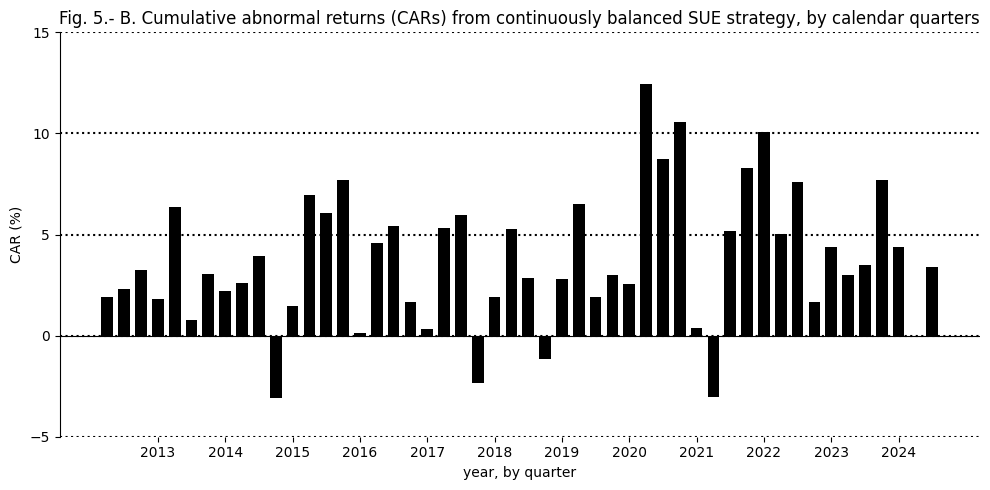

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(len(ls_df_cont)), returns_pct_cont, width=0.7, color='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylim(-5, 15)
ax.set_yticks([-5, 0, 5, 10, 15])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.yaxis.grid(True, linestyle=':', linewidth=1.5, color='black')

ax.set_xlabel('year, by quarter')
ax.set_ylabel('CAR (%)')
ax.set_title('Fig. 5.- B. Cumulative abnormal returns (CARs) from continuously balanced SUE strategy, by calendar quarters')

year_quarters_cont = ls_df_cont['quarter'].tolist()
tick_positions = []
tick_labels = []

for i, q in enumerate(year_quarters_cont):
    if q.endswith('Q1'):
        tick_positions.append(i)
        tick_labels.append(q[:4])

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=10)

plt.tight_layout()
plt.show()

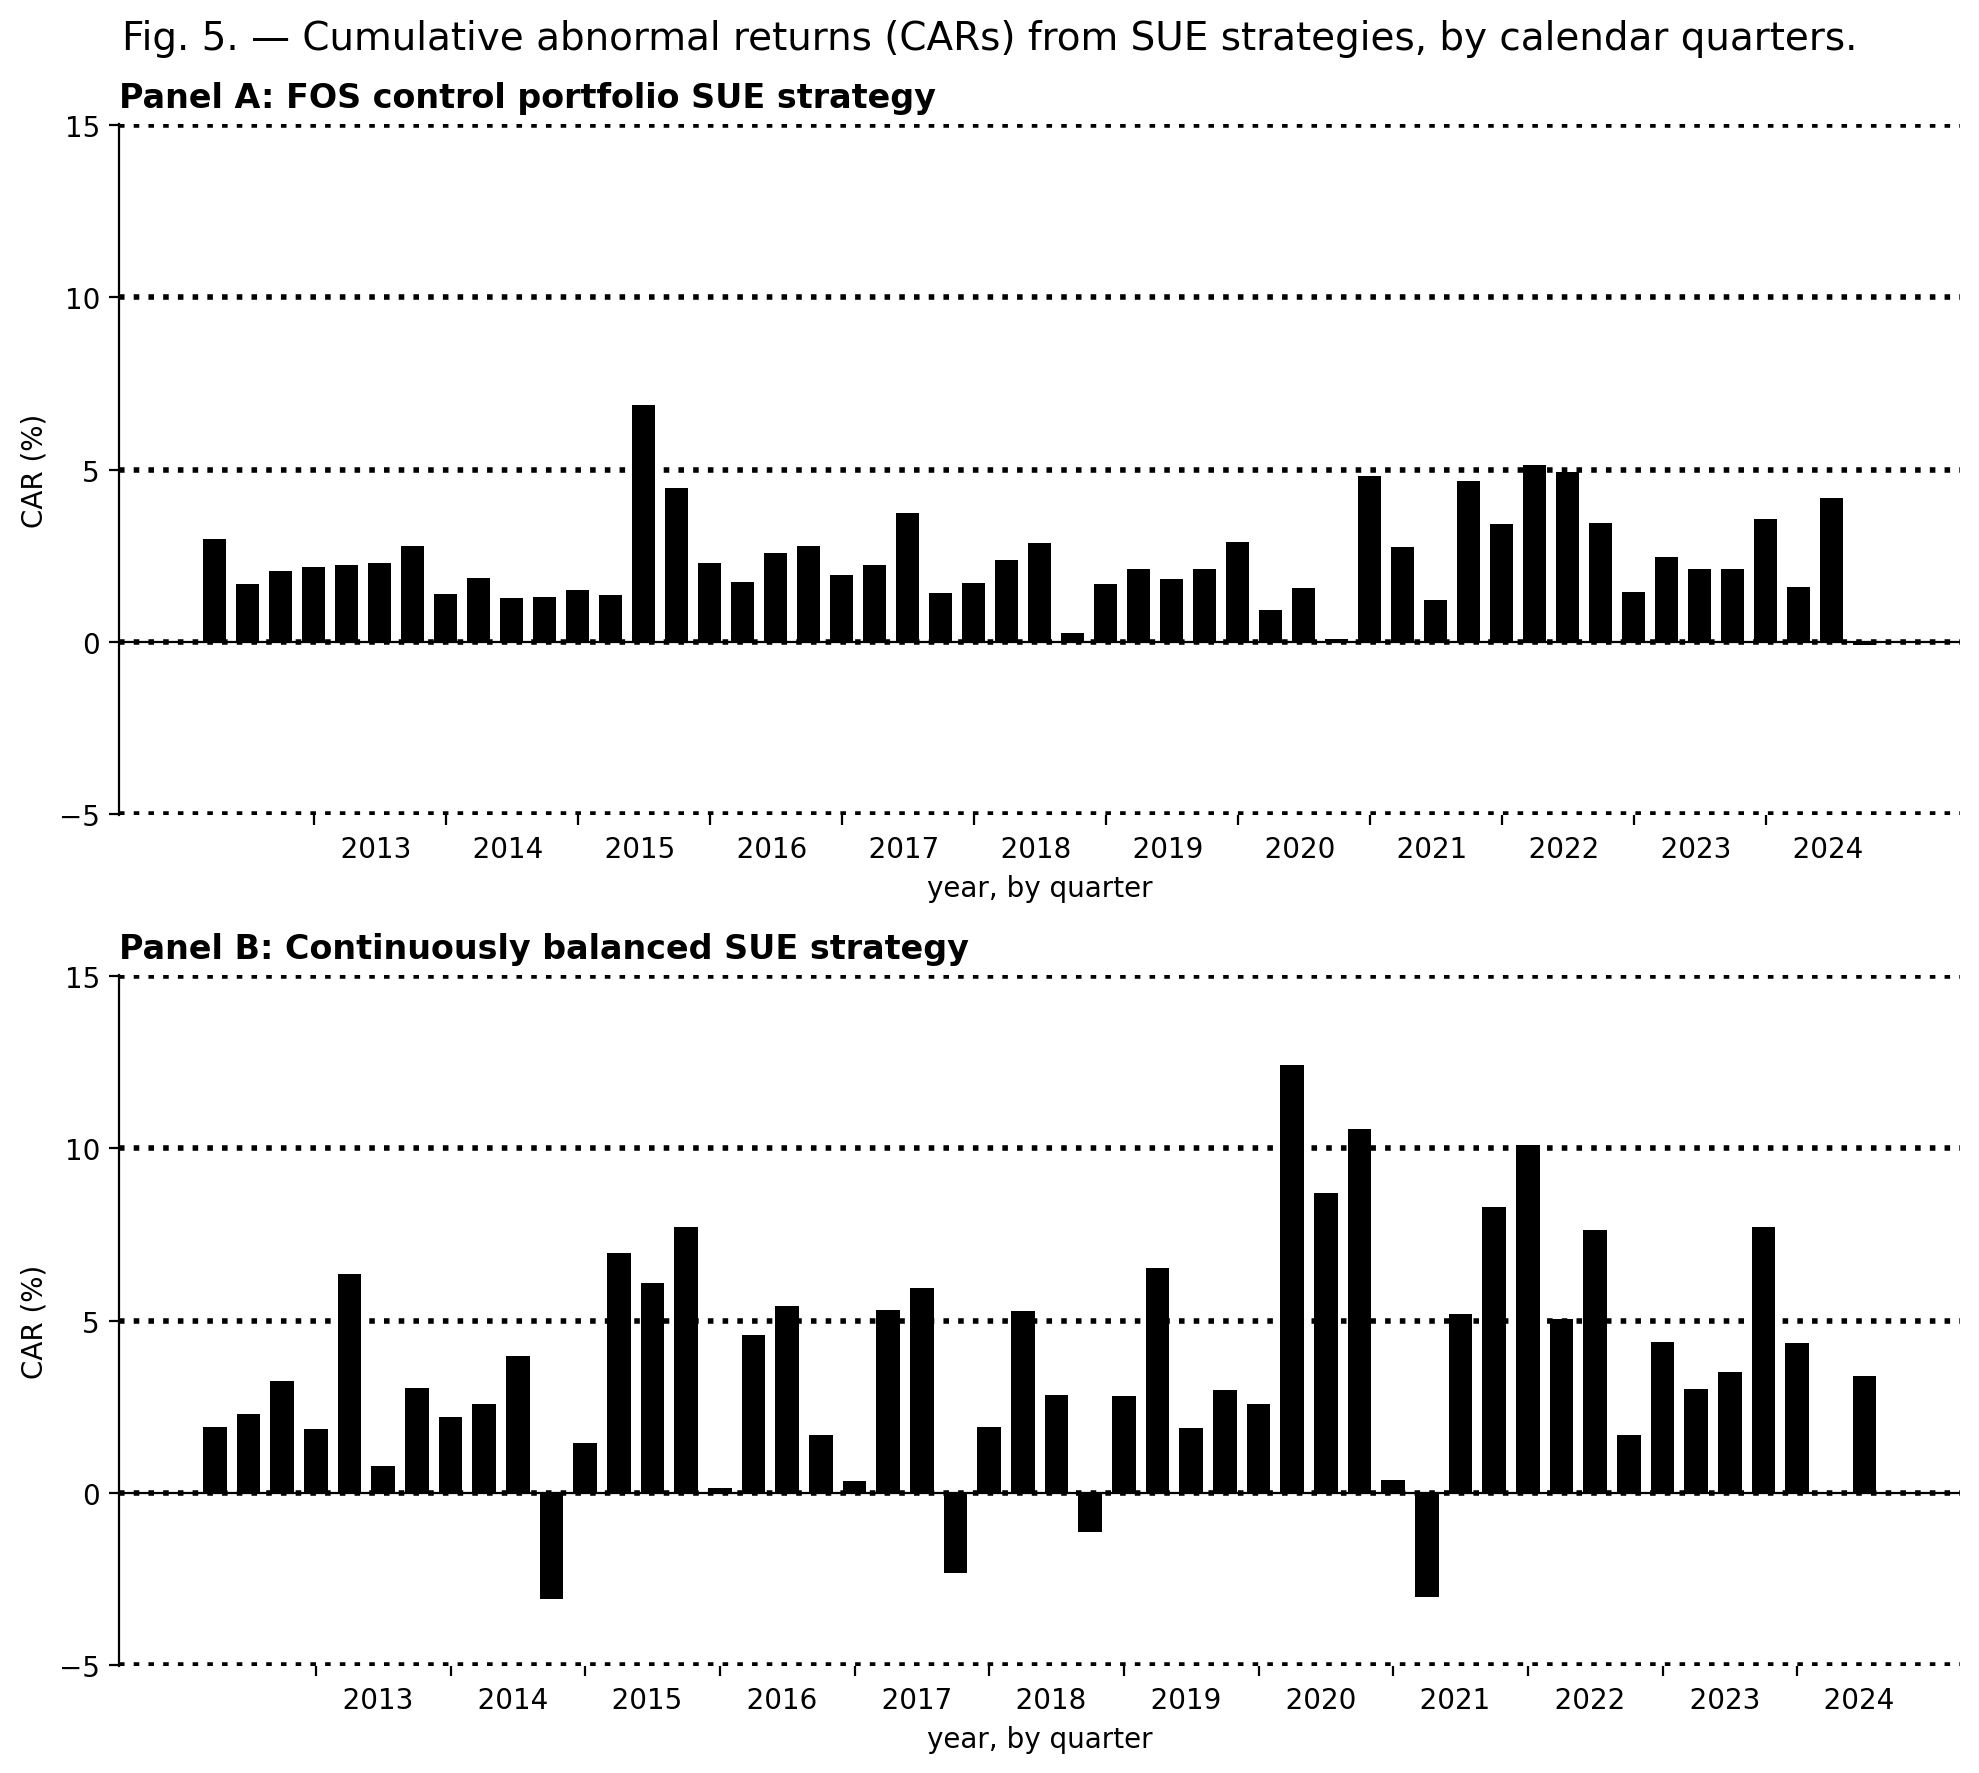

In [39]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=False, dpi=200)

fig.suptitle('Fig. 5. — Cumulative abnormal returns (CARs) from SUE strategies, by calendar quarters.', fontsize=14, y=0.98)


# Panel A
ax1.bar(range(len(ls_df)), returns_pct, width=0.7, color='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_ylim(-5.05, 15.05)
ax1.set_yticks([-5, 0, 5, 10, 15])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

ax1.yaxis.grid(True, linestyle=':', linewidth=2, color='black')

ax1.set_ylabel('CAR (%)')
ax1.set_xlabel('year, by quarter')  
ax1.set_title('Panel A: FOS control portfolio SUE strategy', fontsize=12, loc='left', fontweight='bold')

# X-axis ticks for Panel A
year_quarters = ls_df['quarter'].tolist()
tick_positions = []
tick_labels = []

for i, q in enumerate(year_quarters):
    if q.endswith('Q1'):
        tick_positions.append(i)
        tick_labels.append(q[:4])

ax1.set_xticks(tick_positions)
ax1.set_xticklabels([f'   {l}' for l in tick_labels], ha='left', fontsize=10)



# Panel B
ax2.bar(range(len(ls_df_cont)), returns_pct_cont, width=0.7, color='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_ylim(-5.05, 15.05)
ax2.set_yticks([-5, 0, 5, 10, 15])

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

ax2.yaxis.grid(True, linestyle=':', linewidth=2, color='black')

ax2.set_xlabel('year, by quarter')
ax2.set_ylabel('CAR (%)')
ax2.set_title('Panel B: Continuously balanced SUE strategy', fontsize=12, loc='left', fontweight='bold')

# X-axis ticks (shared)
year_quarters = ls_df['quarter'].tolist()
tick_positions = []
tick_labels = []

for i, q in enumerate(year_quarters):
    if q.endswith('Q1'):
        tick_positions.append(i)
        tick_labels.append(q[:4])

ax2.set_xticks(tick_positions)
ax2.set_xticklabels([f'   {l}' for l in tick_labels], ha='left', fontsize=10)

plt.tight_layout()
plt.show()

## **4.4**

### **Test of whether prices fail to reflect full implications of current earnings for future earnings**

We identify firms in extreme deciles based on the SUE from quarter t. We then examine the average reaction to the announcement of quarter t+1 earnings (measured overdays (-4, 0)) relative to that announcement. 

Table 5 indicates that one can predict the average reaction to quarter t + 1 earnings, based on the SUE for quarter t. When extreme good news arrives in quarter t, the market tends to be "pleasantly surprised" again in quaxrter t + 1, producing average abnormal returns at the second announcement of 1.3%, 0.7%, and 0.3% for small, medium, and large firms, respectively. When extreme bad news arrives in quarter t, the market tends to be "disappointed" again in quarter t + 1, with average abnormal returns at the second announcement being -0.8%, -0.7%, and -0.4% for small, medium, and large firms, respectively.


- take all SUE (deciles alread computed in df_sue_final)
- define D1 and D9 based on the SUE from quarter t
- measure the average reaction to the announcement of quarter t+1 earnings (measured overdays (-4,0)) relative to that announcement. 

For each quarter, we identify extreme deciles firms.

In [40]:
extreme_deciles_t = df_sue_final[df_sue_final['SUE_decile'].isin([1, 10])].copy()
print(extreme_deciles_t.groupby(['fyearq', 'fqtr', 'SUE_decile']).size())
len(extreme_deciles_t)

fyearq  fqtr  SUE_decile
2011    4     1              73
2012    1     1              63
              10             40
        2     1             136
              10            105
                           ... 
2024    2     10            166
        3     1              22
              10             19
        4     1               1
              10              3
Length: 105, dtype: int64


17546

We then link each extreme decile observation from quarter to to their t+1 observation.

In [41]:
df_sue_final['next_fyearq'] = np.where(df_sue_final['fqtr'] == 4, df_sue_final['fyearq'] + 1, df_sue_final['fyearq'])
df_sue_final['next_fqtr'] = np.where(df_sue_final['fqtr'] == 4, 1, df_sue_final['fqtr'] + 1)

# Link t and t+1
df_linked = df_sue_final[df_sue_final['SUE_decile'].isin([1, 10])].copy()
df_linked = df_linked[['gvkey', 'PERMNO', 'fyearq', 'fqtr', 'SUE_decile', 'rdq', 'next_fyearq', 'next_fqtr']].copy()
df_linked = df_linked.rename(columns={'rdq': 'rdq_t'})

df_next = df_sue_final[['gvkey', 'PERMNO', 'fyearq', 'fqtr', 'rdq']].copy()
df_next = df_next.rename(columns={'fyearq': 'next_fyearq', 'fqtr': 'next_fqtr', 'rdq': 'rdq_t1'})

df_linked = df_linked.merge(
    df_next,
    on=['gvkey', 'PERMNO', 'next_fyearq', 'next_fqtr'],
    how='inner'
)

print(f"t and t+1 matches: {len(df_linked)}")
#print(df_linked[['gvkey', 'fyearq', 'fqtr', 'SUE_decile', 'rdq_t', 'rdq_t1']].head())

t and t+1 matches: 16922


We then obtain t+1 (-4, 0) abnormal returns. We use trading days instead of calendar days.

In [42]:
dfD_small = dfD[['PERMNO', 'DlyCalDt', 'DlyAbnReturn']].copy()
dfD_small['DlyCalDt'] = pd.to_datetime(dfD_small['DlyCalDt'])
dfD_small = dfD_small.sort_values(['PERMNO', 'DlyCalDt'])
dfD_small['day_rank'] = dfD_small.groupby('PERMNO').cumcount()


# We use trading days instead of calendar days
rdq_ranks = df_linked[['PERMNO', 'rdq_t1']].merge(
    dfD_small[['PERMNO', 'DlyCalDt', 'day_rank']],
    left_on=['PERMNO', 'rdq_t1'],
    right_on=['PERMNO', 'DlyCalDt'],
    how='left'
).rename(columns={'day_rank': 'rdq_t1_rank'})

rdq_ranks = rdq_ranks.drop_duplicates(subset=['PERMNO', 'rdq_t1'])
df_linked = df_linked.merge(rdq_ranks[['PERMNO', 'rdq_t1', 'rdq_t1_rank']], on=['PERMNO', 'rdq_t1'])

# Vectorized
df_events = df_linked[['gvkey', 'PERMNO', 'fyearq', 'fqtr', 'SUE_decile', 'rdq_t', 'rdq_t1', 'rdq_t1_rank']].copy()

We compute returns for the 4 days window.

In [43]:
event_days = []
for offset in range(-4, 1):  # -4, -3, -2, -1, 0
    temp = df_events.copy()
    temp['offset'] = offset
    temp['target_rank'] = temp['rdq_t1_rank'] + offset
    event_days.append(temp)

df_event_days = pd.concat(event_days, ignore_index=True)

# 1 merge
df_event_days = df_event_days.merge(
    dfD_small[['PERMNO', 'day_rank', 'DlyAbnReturn']],
    left_on=['PERMNO', 'target_rank'],
    right_on=['PERMNO', 'day_rank'],
    how='left'
)

complete_events = df_event_days.groupby(['gvkey', 'PERMNO', 'rdq_t', 'rdq_t1', 'SUE_decile', 'fyearq', 'fqtr'])['DlyAbnReturn'].agg(
    count='count',
    car=lambda x: x.sum()
).reset_index()

# We only keep 5 days returns
complete_events = complete_events[complete_events['count'] == 5].copy()
df_results = complete_events.rename(columns={'car': 'CAR_4_0'}).drop(columns=['count'])

print(f"Quarters with full 5-day returns: {len(df_results)} out of {len(df_linked)}")

Quarters with full 5-day returns: 16922 out of 16922


We also add group types for size based results

In [44]:
sizegroup = pd.read_csv("../data/OOS/SUE_sizegroup.csv")

df_results['gvkey'] = df_results['gvkey'].astype(str)
sizegroup['gvkey'] = sizegroup['gvkey'].astype(str)

df_results = df_results.merge(
    sizegroup[['gvkey', 'fyearq', 'fqtr', 'SizeGroup']],
    on=['gvkey', 'fyearq', 'fqtr'],
    how='left'
)

We can finally obtain results per decile and firm size.

In [45]:
print("D10 (good)")
d10_results = {}
for size in ['small', 'medium', 'large']:
    size_data = df_results[(df_results['SUE_decile'] == 10) & (df_results['SizeGroup'] == size)]
    if len(size_data) > 0:
        mean_car = size_data['CAR_4_0'].mean()
        se = size_data['CAR_4_0'].std() / (len(size_data)**0.5)
        d10_results[size] = mean_car
        print(f"{size.capitalize()}: {mean_car:.2%} ({mean_car/se:.2f})  n={len(size_data)}")

print("\nD1 (bad)")
d1_results = {}
for size in ['small', 'medium', 'large']:
    size_data = df_results[(df_results['SUE_decile'] == 1) & (df_results['SizeGroup'] == size)]
    if len(size_data) > 0:
        mean_car = size_data['CAR_4_0'].mean()
        se = size_data['CAR_4_0'].std() / (len(size_data)**0.5)
        d1_results[size] = mean_car
        print(f"{size.capitalize()}: {mean_car:.2%} ({mean_car/se:.2f})  n={len(size_data)}")

print("\nLong/short difference")
for size in ['small', 'medium', 'large']:
    if size in d10_results and size in d1_results:
        spread = d10_results[size] - d1_results[size]
        print(f"{size.capitalize()}: {spread:.2%}")

D10 (good)
Small: 0.69% (3.21)  n=2209
Medium: 0.08% (0.60)  n=2671
Large: 0.08% (0.90)  n=3595

D1 (bad)
Small: 0.09% (0.41)  n=2065
Medium: 0.19% (1.34)  n=2685
Large: 0.09% (0.92)  n=3592

Long/short difference
Small: 0.60%
Medium: -0.10%
Large: -0.01%


For the "as a fraction of 60-day drift", we just have to use the table 1: 'Diff 1 to 60' numbers for each size.